# Unsupervised Learning Model and Metrics

wanted to use spectral clustering or affinity propagation, but both always kill the kernel & I haven't found a way around it

In [1]:
from util.met_cleaning import clean_met_data
from util.preprocessing import unsupervised_preprocessing, unsupervised_feature_importance
from sklearn.cluster import KMeans#, OPTICS
from itertools import product
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from joblib import load
import numpy as np
import pandas as pd

In [2]:
df = clean_met_data()

In [3]:
X = unsupervised_preprocessing(df)

In [4]:
df.is_significant.value_counts()

is_significant
False    475571
True       9385
Name: count, dtype: int64

## PCA & Feature Importance

In [5]:
pca = PCA(n_components=2).fit(X)
features_pca = pca.transform(X)

In [6]:
importance_df = unsupervised_feature_importance(pca)
importance_df

,feature,importance
0,access_year,0.130
1,age,0.118
2,title,0.113
3,artist_display_name,0.109
4,object_name,0.107
5,medium,0.107
6,artist_nationality,0.100
7,department,0.100
8,country_mapped,0.081
9,culture,0.067


Text(0.5, 1.0, 'Feature Importance After PCA (Cluster-Driven)')

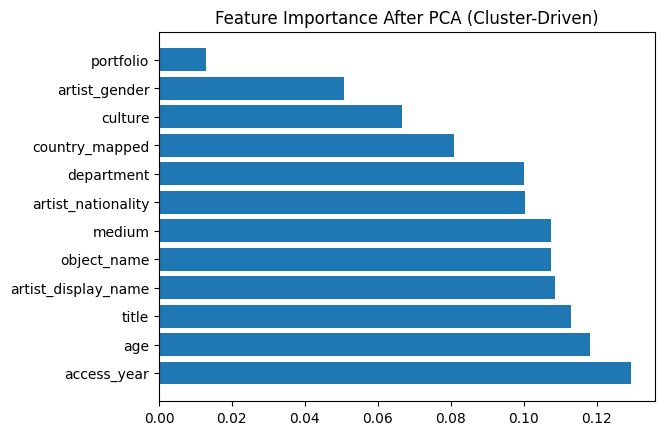

In [7]:
plt.barh(width=importance_df['importance'], y=importance_df['feature'])
plt.title("Feature Importance After PCA (Cluster-Driven)")

## K-Means Clustering

In [8]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto").fit_predict(X)

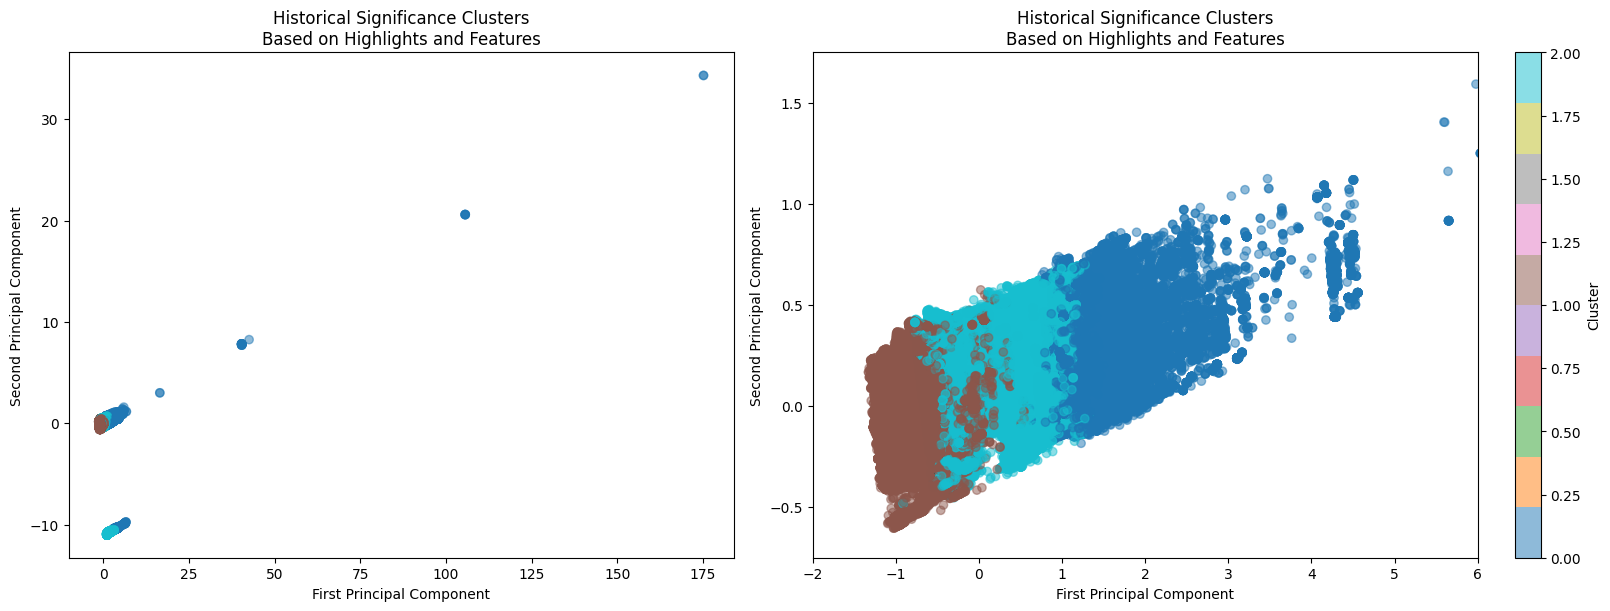

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

scatter1 = ax1.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=kmeans, cmap='tab10', alpha=0.5)
ax1.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax1.set_xlabel('First Principal Component')
ax1.set_ylabel('Second Principal Component')

scatter2 = ax2.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=kmeans, cmap='tab10', alpha=0.5)
ax2.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax2.set_xlabel('First Principal Component')
ax2.set_ylabel('Second Principal Component')
ax2.set_xlim([-2, 6])
ax2.set_ylim([-0.75, 1.75])
cbar2 = fig.colorbar(scatter2, ax=ax2, label='Cluster')

plt.show()

In [10]:
df['significance_cluster_kmeans'] = kmeans
print("K-Means Cluster Analysis:")
for cluster in range(n_clusters):
    cluster_items = df[df['significance_cluster_kmeans'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_items)} items):")
    no_sig = len(cluster_items[cluster_items['is_significant']])
    print(f"Number of significant artworks: {no_sig}")  
    print(f"Percentage of significant artworks: {np.round(no_sig/len(cluster_items)*100,2)}%, ({np.round((no_sig/9385)*100,2)}% of total significant works)")  
    print(f"Average age: {cluster_items['age'].mean():.1f} years")
    countries = cluster_items['country_mapped'].value_counts().head(3)
    print("Top countries:", ', '.join([f"{c} ({n})" for c, n in countries.items() if pd.notna(c)]))
    departments = cluster_items['department'].value_counts().head(3)
    print("Top departments:", ', '.join([f"{c} ({n})" for c, n in departments.items() if pd.notna(c)]))
    mediums = cluster_items['medium'].value_counts().head(3)
    print("Top mediums:", ', '.join([f"{c} ({n})" for c, n in mediums.items() if pd.notna(c)]))

K-Means Cluster Analysis:

Cluster 0 (73480 items):
Number of significant artworks: 1386
Percentage of significant artworks: 1.89%, (14.77% of total significant works)
Average age: 3167.0 years
Top countries: Egypt (30908), Greece (22071), Cyprus (2959)
Top departments: Greek and Roman Art (33600), Egyptian Art (27962), Ancient Near Eastern Art (5428)
Top mediums: Terracotta (23161), Faience (4910), Glass (3983)

Cluster 1 (227646 items):
Number of significant artworks: 2755
Percentage of significant artworks: 1.21%, (29.36% of total significant works)
Average age: 201.6 years
Top countries: United States (83197), France (39797), United Kingdom (24608)
Top departments: Drawings and Prints (170451), Photographs (36546), Modern and Contemporary Art (14222)
Top mediums: Commercial color lithograph (18155), Etching (17237), Engraving (11691)

Cluster 2 (183830 items):
Number of significant artworks: 5244
Percentage of significant artworks: 2.85%, (55.88% of total significant works)
Average

In [11]:
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto").fit_predict(X)

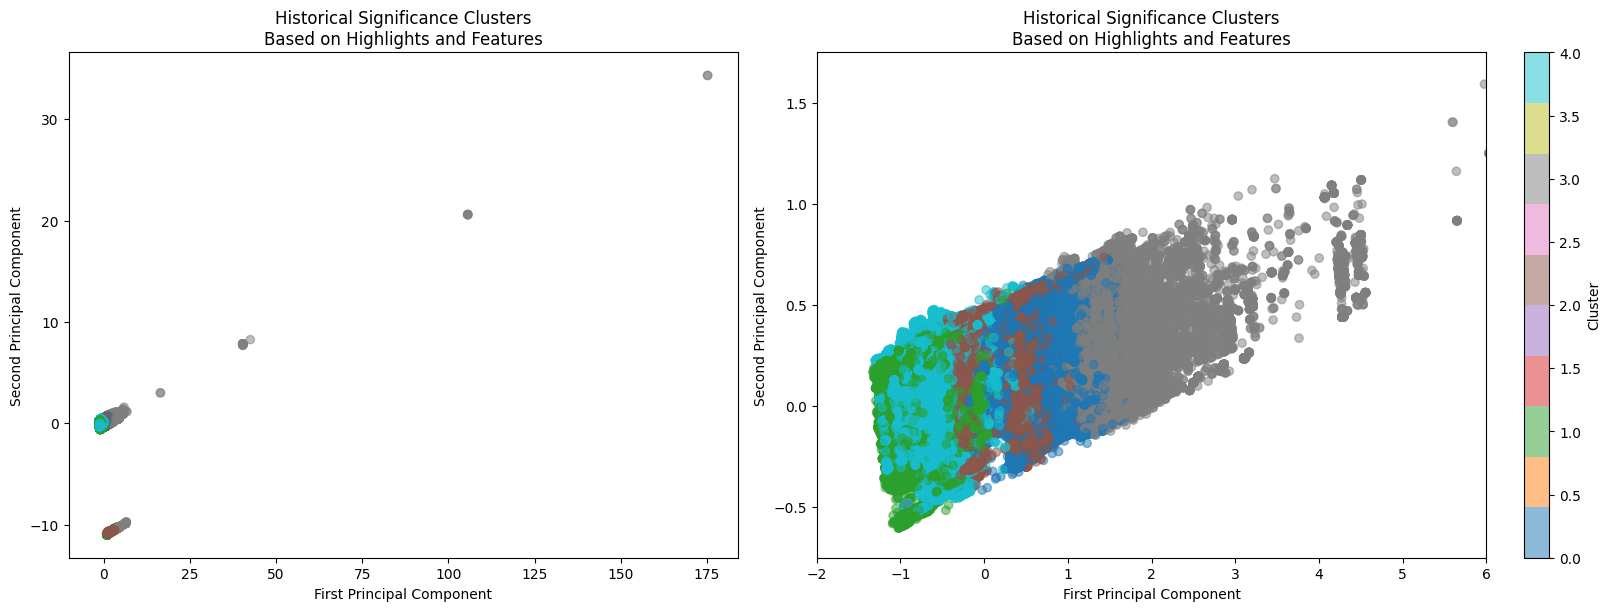

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

scatter1 = ax1.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=kmeans, cmap='tab10', alpha=0.5)
ax1.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax1.set_xlabel('First Principal Component')
ax1.set_ylabel('Second Principal Component')

scatter2 = ax2.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=kmeans, cmap='tab10', alpha=0.5)
ax2.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax2.set_xlabel('First Principal Component')
ax2.set_ylabel('Second Principal Component')
ax2.set_xlim([-2, 6])
ax2.set_ylim([-0.75, 1.75])
cbar2 = fig.colorbar(scatter2, ax=ax2, label='Cluster')

plt.show()

In [13]:
df['significance_cluster_kmeans'] = kmeans
print("K-Means Cluster Analysis:")
for cluster in range(n_clusters):
    cluster_items = df[df['significance_cluster_kmeans'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_items)} items):")
    no_sig = len(cluster_items[cluster_items['is_significant']])
    print(f"Number of significant artworks: {no_sig}")  
    print(f"Percentage of significant artworks: {np.round(no_sig/len(cluster_items)*100,2)}%, ({np.round((no_sig/9385)*100,2)}% of total significant works)")  
    print(f"Average age: {cluster_items['age'].mean():.1f} years")
    countries = cluster_items['country_mapped'].value_counts().head(3)
    print("Top countries:", ', '.join([f"{c} ({n})" for c, n in countries.items() if pd.notna(c)]))
    departments = cluster_items['department'].value_counts().head(3)
    print("Top departments:", ', '.join([f"{c} ({n})" for c, n in departments.items() if pd.notna(c)]))
    mediums = cluster_items['medium'].value_counts().head(3)
    print("Top mediums:", ', '.join([f"{c} ({n})" for c, n in mediums.items() if pd.notna(c)]))

K-Means Cluster Analysis:

Cluster 0 (49604 items):
Number of significant artworks: 1726
Percentage of significant artworks: 3.48%, (18.39% of total significant works)
Average age: 964.7 years
Top countries: Iran (7482), Egypt (5465), Peru (3328)
Top departments: Islamic Art (14741), Arts of Africa, Oceania, and the Americas (11131), Drawings and Prints (5745)
Top mediums: Glass (2767), Commercial color photolithograph (2112), Commercial photolithograph (1667)

Cluster 1 (96390 items):
Number of significant artworks: 1051
Percentage of significant artworks: 1.09%, (11.2% of total significant works)
Average age: 226.8 years
Top countries: France (27545), United States (22593), United Kingdom (14081)
Top departments: Drawings and Prints (76242), Costume Institute (6475), Photographs (4297)
Top mediums: Etching (9006), Engraving (7237), Commercial color lithograph (5860)

Cluster 2 (120664 items):
Number of significant artworks: 2586
Percentage of significant artworks: 2.14%, (27.55% of t

In [14]:
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto").fit_predict(X)

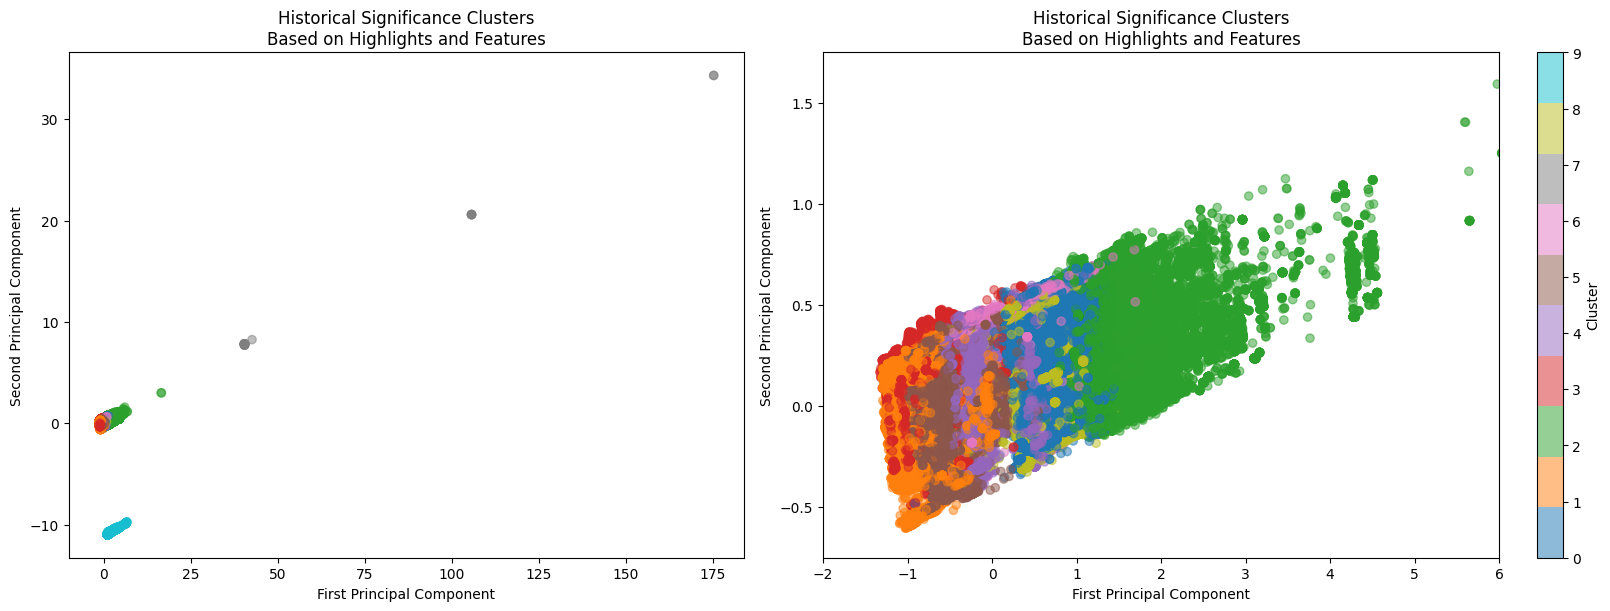

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

scatter1 = ax1.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=kmeans, cmap='tab10', alpha=0.5)
ax1.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax1.set_xlabel('First Principal Component')
ax1.set_ylabel('Second Principal Component')

scatter2 = ax2.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=kmeans, cmap='tab10', alpha=0.5)
ax2.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax2.set_xlabel('First Principal Component')
ax2.set_ylabel('Second Principal Component')
ax2.set_xlim([-2, 6])
ax2.set_ylim([-0.75, 1.75])
cbar2 = fig.colorbar(scatter2, ax=ax2, label='Cluster')

plt.show()

In [16]:
df['significance_cluster_kmeans'] = kmeans
print("K-Means Cluster Analysis:")
for cluster in range(n_clusters):
    cluster_items = df[df['significance_cluster_kmeans'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_items)} items):")
    no_sig = len(cluster_items[cluster_items['is_significant']])
    print(f"Number of significant artworks: {no_sig}")  
    print(f"Percentage of significant artworks: {np.round(no_sig/len(cluster_items)*100,2)}%, ({np.round((no_sig/9385)*100,2)}% of total significant works)")  
    print(f"Average age: {cluster_items['age'].mean():.1f} years")
    countries = cluster_items['country_mapped'].value_counts().head(3)
    print("Top countries:", ', '.join([f"{c} ({n})" for c, n in countries.items() if pd.notna(c)]))
    departments = cluster_items['department'].value_counts().head(3)
    print("Top departments:", ', '.join([f"{c} ({n})" for c, n in departments.items() if pd.notna(c)]))
    mediums = cluster_items['medium'].value_counts().head(3)
    print("Top mediums:", ', '.join([f"{c} ({n})" for c, n in mediums.items() if pd.notna(c)]))

K-Means Cluster Analysis:

Cluster 0 (61282 items):
Number of significant artworks: 1646
Percentage of significant artworks: 2.69%, (17.54% of total significant works)
Average age: 521.2 years
Top countries: United States (12638), France (5568), Japan (5456)
Top departments: Costume Institute (14793), Arms and Armor (12843), Arts of Africa, Oceania, and the Americas (10912)
Top mediums: silk (2002), cotton (1781), Steel (1585)

Cluster 1 (88656 items):
Number of significant artworks: 721
Percentage of significant artworks: 0.81%, (7.68% of total significant works)
Average age: 230.7 years
Top countries: France (23944), United States (22358), United Kingdom (12885)
Top departments: Drawings and Prints (75091), Photographs (4318), Costume Institute (3933)
Top mediums: Etching (8862), Engraving (7219), Commercial color lithograph (5860)

Cluster 2 (66710 items):
Number of significant artworks: 1254
Percentage of significant artworks: 1.88%, (13.36% of total significant works)
Average age:

## K-Means Hyperparameter Tuning

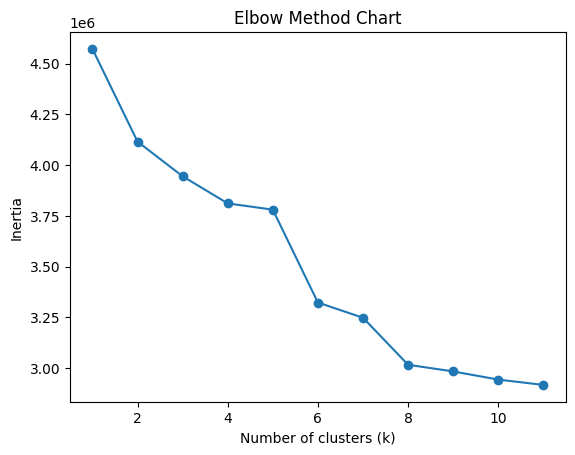

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(1, 12)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method Chart')
plt.show()

In [18]:
# best_k = 6

# best_score = -1
# best_params = {}

# for init_method, n_init_val in product(['k-means++', 'random'], [10, 20]):
#     kmeans = KMeans(n_clusters=best_k, init=init_method, n_init=n_init_val, random_state=42).fit_predict(X)
#     score = silhouette_score(X, kmeans)
#     print(f"Method for initialization: {init_method}")
#     print(f"Initialization value: {n_init_val}")
#     print(f"Score: {score}")

#     if score > best_score:
#         best_score = score
#         best_params = {'init': init_method, 'n_init': n_init_val}

# print("Best score:", best_score)
# print("Best params:", best_params)

output: 

Method for initialization: k-means++\
Initialization value: 10\
Score: 0.09499261696822331\
Method for initialization: k-means++\
Initialization value: 20\
Score: 0.09009427848052647\
Method for initialization: random\
Initialization value: 10\
Score: 0.08792924572406849\
Method for initialization: random\
Initialization value: 20\
Score: 0.09166159548825276\
Best score: 0.09499261696822331\
Best params: {'init': 'k-means++', 'n_init': 10}

### Best K-means clustering

In [19]:
best_k = 6
best_params = {'init': 'k-means++', 'n_init': 10}
kmeans = KMeans(n_clusters=best_k, random_state=42, init=best_params['init'], n_init=best_params['n_init']).fit_predict(X)

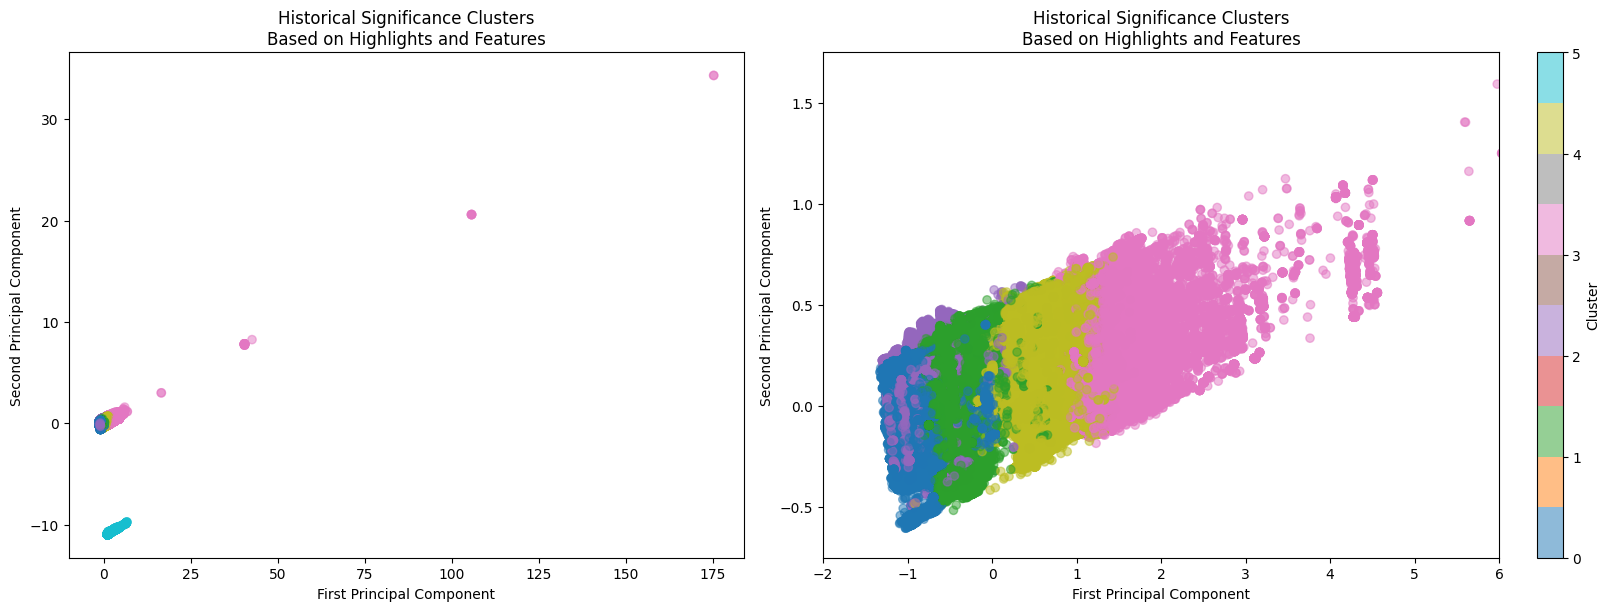

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

scatter1 = ax1.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=kmeans, cmap='tab10', alpha=0.5)
ax1.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax1.set_xlabel('First Principal Component')
ax1.set_ylabel('Second Principal Component')

scatter2 = ax2.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=kmeans, cmap='tab10', alpha=0.5)
ax2.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax2.set_xlabel('First Principal Component')
ax2.set_ylabel('Second Principal Component')
ax2.set_xlim([-2, 6])
ax2.set_ylim([-0.75, 1.75])
cbar2 = fig.colorbar(scatter2, ax=ax2, label='Cluster')

plt.show()

In [21]:
df['significance_cluster_kmeans'] = kmeans
print("Best K-Means Cluster Analysis:")
for cluster in range(best_k):
    cluster_items = df[df['significance_cluster_kmeans'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_items)} items):")
    no_sig = len(cluster_items[cluster_items['is_significant']])
    print(f"Number of significant artworks: {no_sig}")        
    print(f"Percentage of significant artworks: {np.round(no_sig/len(cluster_items)*100,2)}%, ({np.round((no_sig/9385)*100,2)}% of total significant works)")  
    print(f"Average age: {cluster_items['age'].mean():.1f} years")
    countries = cluster_items['country_mapped'].value_counts().head(3)
    print("Top countries:", ', '.join([f"{c} ({n})" for c, n in countries.items() if pd.notna(c)]))
    departments = cluster_items['department'].value_counts().head(3)
    print("Top departments:", ', '.join([f"{c} ({n})" for c, n in departments.items() if pd.notna(c)]))
    mediums = cluster_items['medium'].value_counts().head(3)
    print("Top mediums:", ', '.join([f"{c} ({n})" for c, n in mediums.items() if pd.notna(c)]))

Best K-Means Cluster Analysis:

Cluster 0 (99296 items):
Number of significant artworks: 508
Percentage of significant artworks: 0.51%, (5.41% of total significant works)
Average age: 261.5 years
Top countries: France (25469), United States (18965), Italy (16605)
Top departments: Drawings and Prints (98965), Modern and Contemporary Art (297), Asian Art (18)
Top mediums: Etching (15051), Engraving (10326), Commercial color lithograph (5876)

Cluster 1 (96022 items):
Number of significant artworks: 2999
Percentage of significant artworks: 3.12%, (31.96% of total significant works)
Average age: 216.8 years
Top countries: France (25606), United Kingdom (15157), Italy (9097)
Top departments: Drawings and Prints (33793), Photographs (15231), European Sculpture and Decorative Arts (13841)
Top mediums: Albumen silver print from glass negative (3447), Commercial color lithograph (3330), Gelatin silver print (3247)

Cluster 2 (82454 items):
Number of significant artworks: 1394
Percentage of sign

## OPTICS Clustering

min_samples = 100

In [22]:
# optics = OPTICS(min_samples=100, n_jobs=-1).fit(features_pca)
optics = load('../models/unsupervised/optics_ms100.pkl.lzma')
optics_ms100 = optics.labels_

In [23]:
df['significance_cluster_optics'] = optics_ms100
print(f"Number of clusters: {len(set(optics_ms100))}")

Number of clusters: 903


In [24]:
# print(silhouette_score(X, optics_ms100))

silhouette score: -0.154338678405048

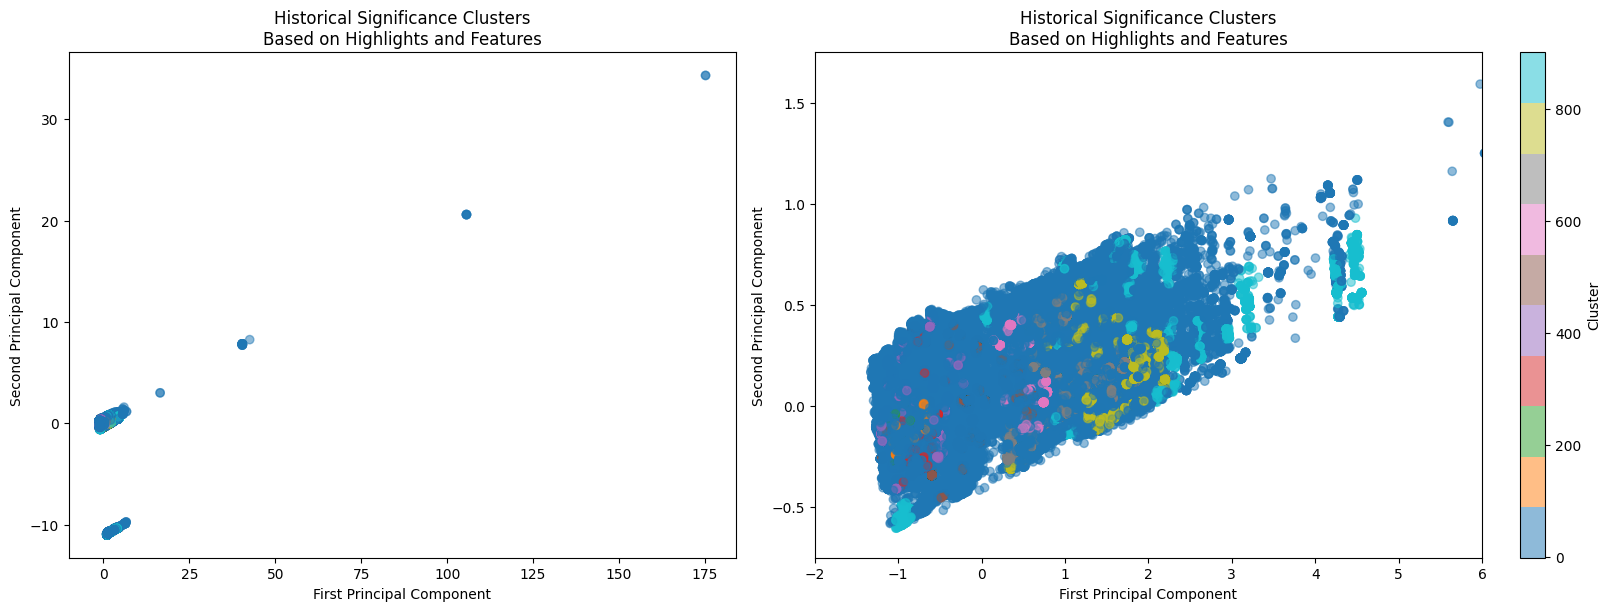

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

scatter1 = ax1.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=optics_ms100, cmap='tab10', alpha=0.5)
ax1.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax1.set_xlabel('First Principal Component')
ax1.set_ylabel('Second Principal Component')

scatter2 = ax2.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=optics_ms100, cmap='tab10', alpha=0.5)
ax2.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax2.set_xlabel('First Principal Component')
ax2.set_ylabel('Second Principal Component')
ax2.set_xlim([-2, 6])
ax2.set_ylim([-0.75, 1.75])
cbar2 = fig.colorbar(scatter2, ax=ax2, label='Cluster')

plt.show()

In [26]:
print("OPTICS Cluster Sample Analysis (min_samples = 100):")
for cluster in range(10):
    cluster_items = df[df['significance_cluster_optics'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_items)} items):")
    no_sig = len(cluster_items[cluster_items['is_significant']])
    print(f"Number of significant artworks: {no_sig}")  
    print(f"Percentage of significant artworks: {np.round(no_sig/len(cluster_items)*100,2)}%, ({np.round((no_sig/9385)*100,2)}% of total significant works)")  
    print(f"Average age: {cluster_items['age'].mean():.1f} years")
    countries = cluster_items['country_mapped'].value_counts().head(3)
    print("Top countries:", ', '.join([f"{c} ({n})" for c, n in countries.items() if pd.notna(c)]))
    cultures = cluster_items['culture'].value_counts().head(3)
    print("Top cultures:", ', '.join([f"{c} ({n})" for c, n in cultures.items() if pd.notna(c)]))
    mediums = cluster_items['medium'].value_counts().head(3)
    print("Top mediums:", ', '.join([f"{c} ({n})" for c, n in mediums.items() if pd.notna(c)]))

OPTICS Cluster Sample Analysis (min_samples = 100):

Cluster 0 (360 items):
Number of significant artworks: 5
Percentage of significant artworks: 1.39%, (0.05% of total significant works)
Average age: 147.6 years
Top countries: United Kingdom (311), Japan (38), United States (3)
Top cultures: Japanese (38), American (3), Italian (1)
Top mediums: Albumen silver print from glass negative (249), Albumen silver print (21), synthetic (15)

Cluster 1 (106 items):
Number of significant artworks: 4
Percentage of significant artworks: 3.77%, (0.04% of total significant works)
Average age: 154.2 years
Top countries: United States (11), Mexico (6), Italy (2)
Top cultures: American (11), French (1)
Top mediums: Albumen silver print from glass negative (81), Graphite on off-white wove paper (8), Oil on canvas (3)

Cluster 2 (138 items):
Number of significant artworks: 4
Percentage of significant artworks: 2.9%, (0.04% of total significant works)
Average age: 147.2 years
Top countries: United States

min_samples = 1000

In [27]:
# optics_ms1000 = OPTICS(min_samples=1000, n_jobs=-1).fit_predict(features_pca)
optics_ms1000 = load('../models/unsupervised/optics_ms1000.pkl.lzma')

In [28]:
df['significance_cluster_optics'] = optics_ms1000
print(f"Number of clusters: {len(set(optics_ms1000))}")

Number of clusters: 28


In [29]:
# print(silhouette_score(X, optics_ms1000))

silhouette_score: -0.1612416349772161

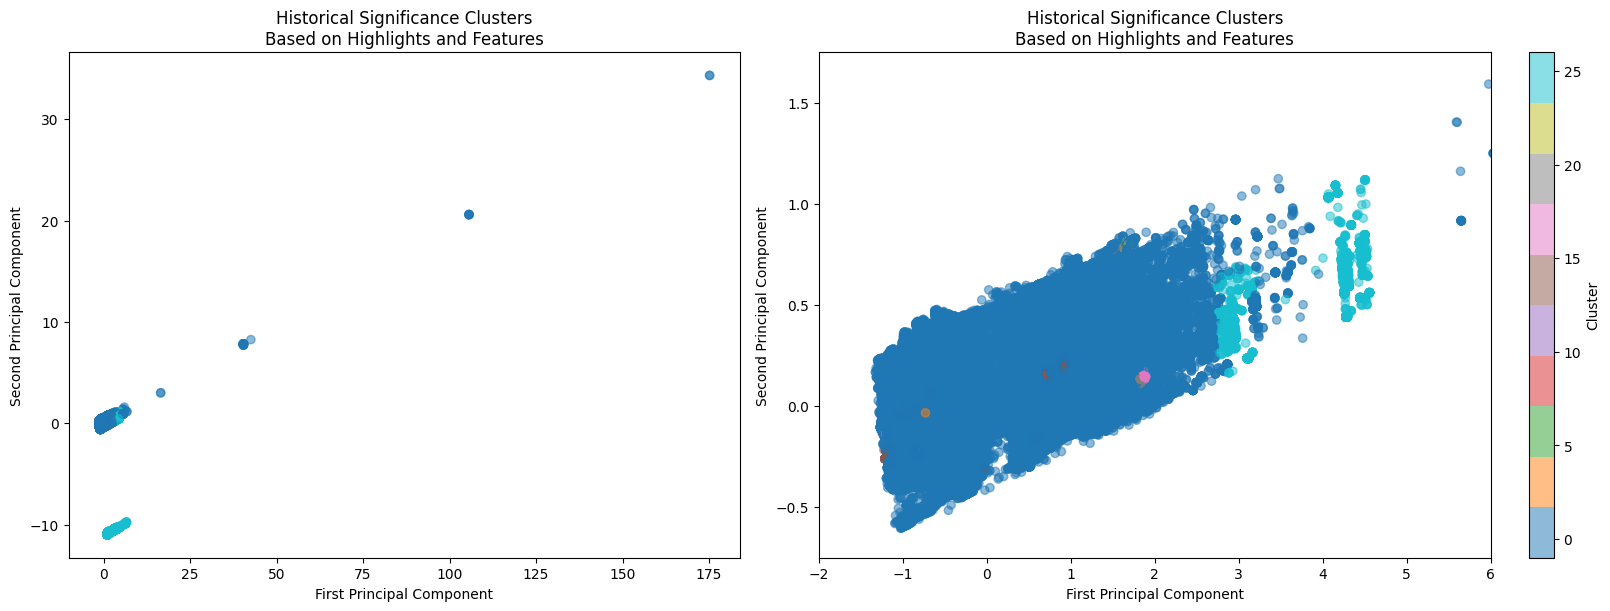

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

scatter1 = ax1.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=optics_ms1000, cmap='tab10', alpha=0.5)
ax1.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax1.set_xlabel('First Principal Component')
ax1.set_ylabel('Second Principal Component')

scatter2 = ax2.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=optics_ms1000, cmap='tab10', alpha=0.5)
ax2.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax2.set_xlabel('First Principal Component')
ax2.set_ylabel('Second Principal Component')
ax2.set_xlim([-2, 6])
ax2.set_ylim([-0.75, 1.75])
cbar2 = fig.colorbar(scatter2, ax=ax2, label='Cluster')

plt.show()

In [31]:
print("OPTICS Cluster Sample Analysis (min_samples = 1000):")
for cluster in range(10):
    cluster_items = df[df['significance_cluster_optics'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_items)} items):")
    no_sig = len(cluster_items[cluster_items['is_significant']])
    print(f"Number of significant artworks: {no_sig}")  
    print(f"Percentage of significant artworks: {np.round(no_sig/len(cluster_items)*100,2)}%, ({np.round((no_sig/9385)*100,2)}% of total significant works)")  
    print(f"Average age: {cluster_items['age'].mean():.1f} years")
    countries = cluster_items['country_mapped'].value_counts().head(3)
    print("Top countries:", ', '.join([f"{c} ({n})" for c, n in countries.items() if pd.notna(c)]))
    cultures = cluster_items['culture'].value_counts().head(3)
    print("Top cultures:", ', '.join([f"{c} ({n})" for c, n in cultures.items() if pd.notna(c)]))
    mediums = cluster_items['medium'].value_counts().head(3)
    print("Top mediums:", ', '.join([f"{c} ({n})" for c, n in mediums.items() if pd.notna(c)]))

OPTICS Cluster Sample Analysis (min_samples = 1000):

Cluster 0 (1113 items):
Number of significant artworks: 0
Percentage of significant artworks: 0.0%, (0.0% of total significant works)
Average age: 90.0 years
Top countries: United States (1113)
Top cultures: 
Top mediums: Film negative (1113)

Cluster 1 (1213 items):
Number of significant artworks: 0
Percentage of significant artworks: 0.0%, (0.0% of total significant works)
Average age: 144.7 years
Top countries: Italy (20), France (5), United Kingdom (3)
Top cultures: Spanish (1), French (1)
Top mediums: Albumen photograph (1172), Etching (6), Gelatin silver print (3)

Cluster 2 (1198 items):
Number of significant artworks: 0
Percentage of significant artworks: 0.0%, (0.0% of total significant works)
Average age: 120.6 years
Top countries: France (52), United Kingdom (14), Germany (2)
Top cultures: French (5)
Top mediums: Commercial color lithograph (1127), Watercolor and  gouache (bodycolor) (7), Pen and ink with wash (6)

Cluste

min_samples = 10000

In [32]:
# optics_ms10000 = OPTICS(min_samples=10000, n_jobs=-1).fit_predict(features_pca)
optics_ms10000 = load('../models/unsupervised/optics_ms10000.pkl.lzma')

In [33]:
df['significance_cluster_optics'] = optics_ms10000
print(f"Number of clusters: {len(set(optics_ms10000))}")

Number of clusters: 2


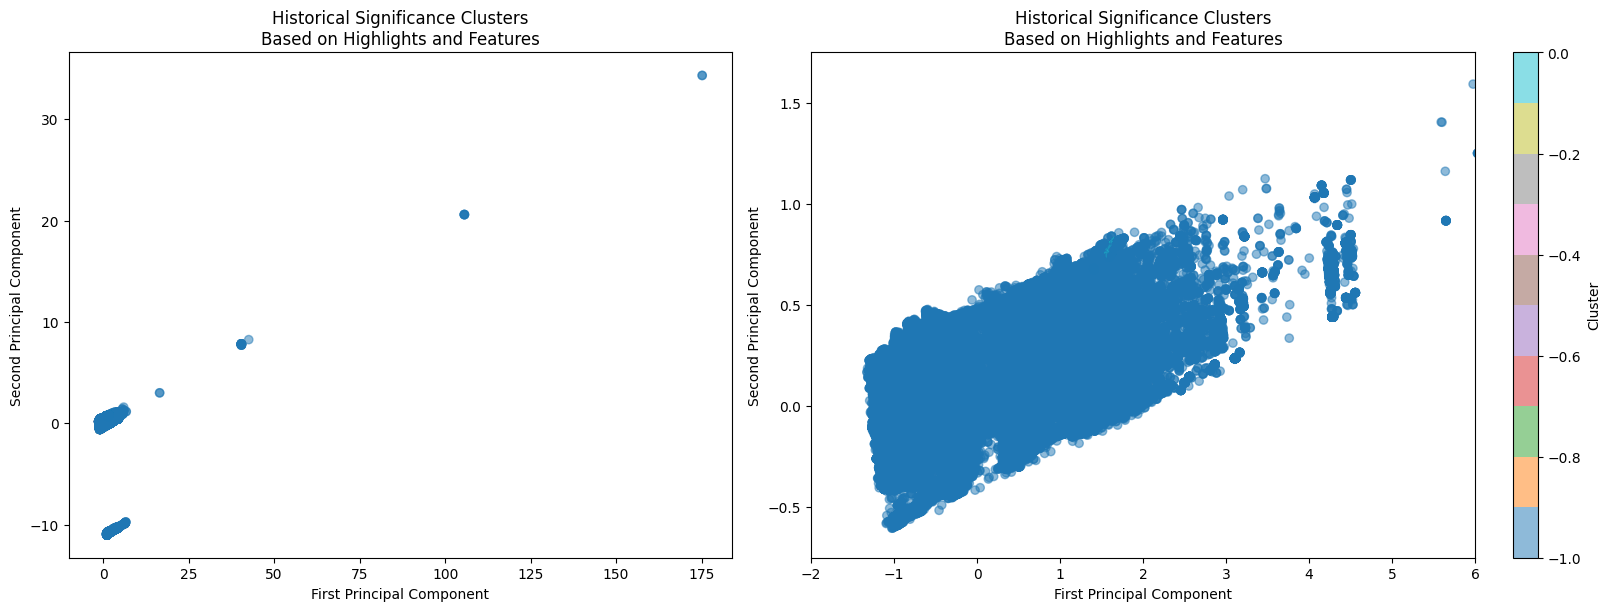

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

scatter1 = ax1.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=optics_ms10000, cmap='tab10', alpha=0.5)
ax1.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax1.set_xlabel('First Principal Component')
ax1.set_ylabel('Second Principal Component')

scatter2 = ax2.scatter(features_pca[:, 0], features_pca[:, 1], 
                       c=optics_ms10000, cmap='tab10', alpha=0.5)
ax2.set_title('Historical Significance Clusters\nBased on Highlights and Features')
ax2.set_xlabel('First Principal Component')
ax2.set_ylabel('Second Principal Component')
ax2.set_xlim([-2, 6])
ax2.set_ylim([-0.75, 1.75])
cbar2 = fig.colorbar(scatter2, ax=ax2, label='Cluster')

plt.show()

In [35]:
print("OPTICS Cluster Sample Analysis (min_samples = 10000):")
cluster_items = df[df['significance_cluster_optics'] == 0]
print(f"\nCluster 0 ({len(cluster_items)} items):")
no_sig = len(cluster_items[cluster_items['is_significant']])
print(f"Number of significant artworks: {no_sig}")  
print(f"Percentage of significant artworks: {np.round(no_sig/len(cluster_items)*100,2)}%, ({np.round((no_sig/9385)*100,2)}% of total significant works)")  
print(f"Average age: {cluster_items['age'].mean():.1f} years")
countries = cluster_items['country_mapped'].value_counts().head(3)
print("Top countries:", ', '.join([f"{c} ({n})" for c, n in countries.items() if pd.notna(c)]))
cultures = cluster_items['culture'].value_counts().head(3)
print("Top cultures:", ', '.join([f"{c} ({n})" for c, n in cultures.items() if pd.notna(c)]))
mediums = cluster_items['medium'].value_counts().head(3)
print("Top mediums:", ', '.join([f"{c} ({n})" for c, n in mediums.items() if pd.notna(c)]))

OPTICS Cluster Sample Analysis (min_samples = 10000):

Cluster 0 (10304 items):
Number of significant artworks: 0
Percentage of significant artworks: 0.0%, (0.0% of total significant works)
Average age: 2550.3 years
Top countries: Greece (10077), Italy (214), Egypt (3)
Top cultures: Greek, Attic (10006), Etruscan (201), Greek, South Italian, Apulian (18)
Top mediums: Terracotta (10300), Faience (2), Basalt or metagraywacke (1)
